In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **IMDB Reviews** untuk binary sentiment classification.

- **Sumber Dataset**: `keras.datasets.imdb`
- **Jumlah Data**: 50.000 ulasan film
- **Label**: 0 = Negatif, 1 = Positif
- **Tipe Data**: Teks (ulasan film bahasa Inggris)

# **2. Import Library**

Mengimpor pustaka yang dibutuhkan untuk analisis dan preprocessing data teks.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import os
from collections import Counter
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("All libraries imported successfully.")

All libraries imported successfully.


# **3. Memuat Dataset**

Dataset IMDB dimuat dari `keras.datasets.imdb`. Data berupa sequence integer akan didekode kembali ke teks asli.

In [17]:
MAX_VOCAB_SIZE = 20000

(train_seqs, train_labels), (test_seqs, test_labels) = imdb.load_data(num_words=MAX_VOCAB_SIZE)
print(f"Train samples: {len(train_seqs)}, Test samples: {len(test_seqs)}")

all_seqs = np.concatenate([train_seqs, test_seqs])
all_labels = np.concatenate([train_labels, test_labels])

word_index = imdb.get_word_index()
reverse_index = {v + 3: k for k, v in word_index.items()}
reverse_index[0] = "<PAD>"
reverse_index[1] = "<START>"
reverse_index[2] = "<OOV>"

texts = []
for seq in all_seqs:
    decoded = " ".join([reverse_index.get(i, "?") for i in seq])
    texts.append(decoded)

df = pd.DataFrame({"text": texts, "label": all_labels})
print(f"Dataset shape: {df.shape}")
display(df.head())

# ===================== SIMPAN DATASET RAW =====================
RAW_OUTPUT_DIR = "/content/drive/MyDrive/MY PROJECT/Hackathon x Digdaya 2026/Membangun Sistem Machine Learning/dataset_raw"
os.makedirs(RAW_OUTPUT_DIR, exist_ok=True)

raw_csv_path = os.path.join(RAW_OUTPUT_DIR, "imdb_reviews_raw.csv")
df.to_csv(raw_csv_path, index=False)
print(f"Dataset raw disimpan di: {raw_csv_path}")


Train samples: 25000, Test samples: 25000
Dataset shape: (50000, 2)


,text,label
0,<START> this film was just brilliant casting l...,1
1,<START> big hair big boobs bad music and a gia...,0
2,<START> this has to be one of the worst films ...,0
3,<START> the scots excel at storytelling the tr...,1
4,<START> worst mistake of my life br br i picke...,0


Dataset raw disimpan di: /content/drive/MyDrive/MY PROJECT/Hackathon x Digdaya 2026/Membangun Sistem Machine Learning/dataset_raw/imdb_reviews_raw.csv


# **4. Exploratory Data Analysis (EDA)**

Melakukan eksplorasi data untuk memahami karakteristik dataset sebelum preprocessing.

DATASET SHAPE
Rows: 50000, Columns: 2

COLUMN INFORMATION
text     object
label     int64
dtype: object

MISSING VALUES
text     0
label    0
dtype: int64

DUPLICATE ROWS
Duplicates: 420

CLASS DISTRIBUTION
label
1    25000
0    25000
Name: count, dtype: int64
label
1    50.0
0    50.0
Name: proportion, dtype: float64


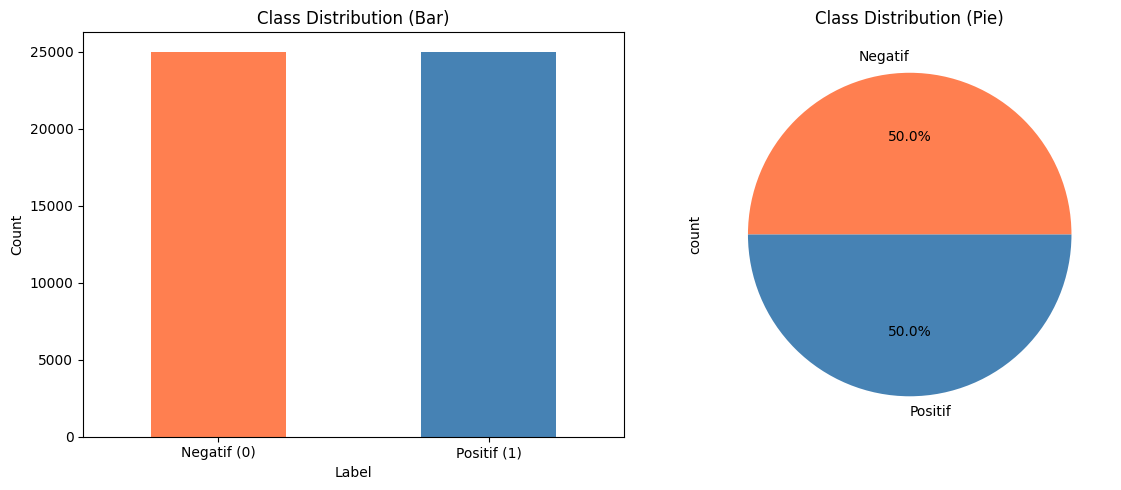


TEXT LENGTH ANALYSIS
Average text length: 234.76 words
Min: 7, Max: 2494
Median: 176.0


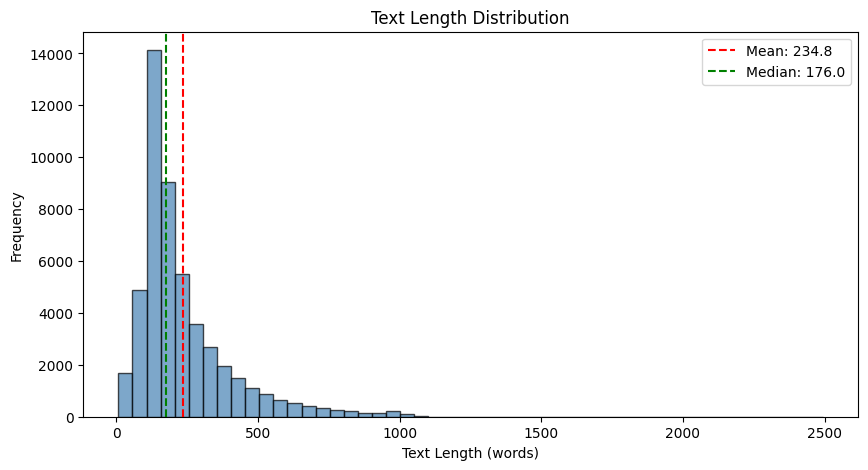


WORD FREQUENCY (Top 10)
Vocabulary size: 19997
Top 10 words:
  the: 666757
  and: 324337
  a: 322800
  <OOV>: 303068
  of: 289379
  to: 268079
  is: 211041
  br: 201951
  in: 186690
  it: 156801


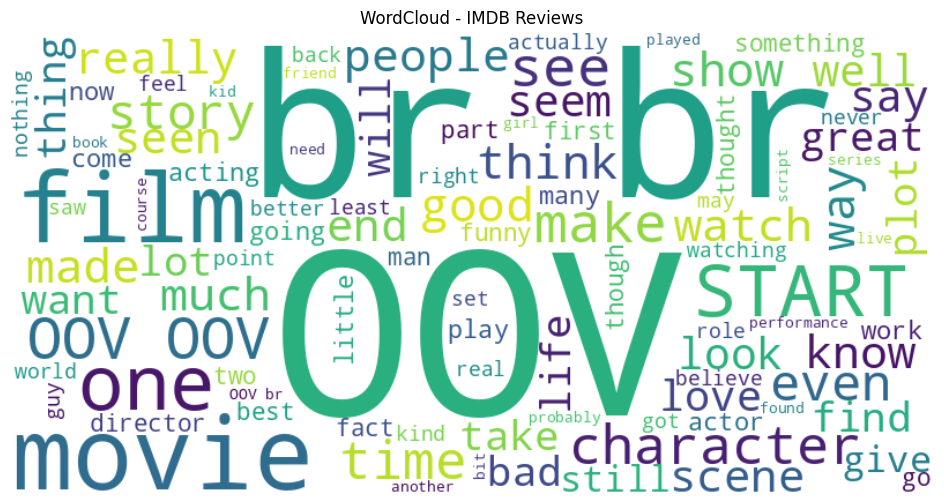


EDA completed. All visualizations saved.


In [18]:
OUTPUT_DIR = "/content/drive/MyDrive/MY PROJECT/Hackathon x Digdaya 2026/Membangun Sistem Machine Learning/preprocessing"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 4a. Dataset shape
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()

# 4b. Column information
print("=" * 50)
print("COLUMN INFORMATION")
print("=" * 50)
print(df.dtypes)
print()

# 4c. Missing values
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print()

# 4d. Duplicate rows
print("=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
print(f"Duplicates: {df.duplicated().sum()}")
print()

# 4e. Class distribution
print("=" * 50)
print("CLASS DISTRIBUTION")
print("=" * 50)
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True) * 100)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df["label"].value_counts().plot(kind="bar", color=["coral", "steelblue"])
plt.title("Class Distribution (Bar)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Negatif (0)", "Positif (1)"], rotation=0)

plt.subplot(1, 2, 2)
df["label"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["coral", "steelblue"], labels=["Negatif", "Positif"])
plt.title("Class Distribution (Pie)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"))
plt.show()
print()

# 4f. Text length distribution
print("=" * 50)
print("TEXT LENGTH ANALYSIS")
print("=" * 50)
df["text_length"] = df["text"].apply(lambda x: len(x.split()))
print(f"Average text length: {df['text_length'].mean():.2f} words")
print(f"Min: {df['text_length'].min()}, Max: {df['text_length'].max()}")
print(f"Median: {df['text_length'].median()}")

plt.figure(figsize=(10, 5))
plt.hist(df["text_length"], bins=50, color="steelblue", edgecolor="black", alpha=0.7)
plt.axvline(df["text_length"].mean(), color="red", linestyle="--", label=f"Mean: {df['text_length'].mean():.1f}")
plt.axvline(df["text_length"].median(), color="green", linestyle="--", label=f"Median: {df['text_length'].median():.1f}")
plt.xlabel("Text Length (words)")
plt.ylabel("Frequency")
plt.title("Text Length Distribution")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "text_length_distribution.png"))
plt.show()
print()

# 4g. Word frequency
print("=" * 50)
print("WORD FREQUENCY (Top 10)")
print("=" * 50)
all_words = " ".join(df["text"]).split()
word_freq = Counter(all_words)
print(f"Vocabulary size: {len(word_freq)}")
print("Top 10 words:")
for word, freq in word_freq.most_common(10):
    print(f"  {word}: {freq}")

# 4h. WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white", max_words=100).generate(" ".join(df["text"]))
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - IMDB Reviews")
plt.savefig(os.path.join(OUTPUT_DIR, "wordcloud.png"))
plt.show()
print()

print("EDA completed. All visualizations saved.")

# **5. Data Preprocessing**

Tahapan preprocessing:
1. Cleaning: lowercase, hapus URL, HTML tag, username, punctuation, angka, normalize whitespace
2. Hapus duplikat & missing values
3. Tokenisasi & padding
4. Label encoding
5. Train/Validation/Test split
6. Simpan hasil preprocessing ke folder `dataset_preprocessing/`

In [19]:
# ===================== CLEANING =====================
def clean_text(text):
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_clean = df.copy()
df_clean.drop_duplicates(inplace=True)
df_clean.dropna(inplace=True)
df_clean["text"] = df_clean["text"].apply(clean_text)
df_clean = df_clean[df_clean["text"].str.strip() != ""]

print(f"After cleaning: {df_clean.shape}")

# ===================== TOKENIZATION & PADDING =====================
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df_clean["text"])
sequences = tokenizer.texts_to_sequences(df_clean["text"])
padded = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")

print(f"Padded sequences shape: {padded.shape}")

with open(os.path.join(OUTPUT_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved.")

# ===================== LABEL ENCODING =====================
encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(df_clean["label"])

with open(os.path.join(OUTPUT_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(encoder, f)
print(f"Label encoder saved. Classes: {encoder.classes_}")

# ===================== TRAIN/VAL/TEST SPLIT =====================
RANDOM_SEED = 42
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.1

X_train_val, X_test, y_train_val, y_test = train_test_split(
    padded, labels_encoded, test_size=TEST_SPLIT, random_state=RANDOM_SEED, stratify=labels_encoded
)
val_frac = VALIDATION_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_frac, random_state=RANDOM_SEED, stratify=y_train_val
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train labels: {y_train.shape}, Val labels: {y_val.shape}, Test labels: {y_test.shape}")

# ===================== SAVE PREPROCESSED DATA =====================
np.save(os.path.join(OUTPUT_DIR, "X_train.npy"), X_train)
np.save(os.path.join(OUTPUT_DIR, "X_val.npy"), X_val)
np.save(os.path.join(OUTPUT_DIR, "X_test.npy"), X_test)
np.save(os.path.join(OUTPUT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(OUTPUT_DIR, "y_val.npy"), y_val)
np.save(os.path.join(OUTPUT_DIR, "y_test.npy"), y_test)

print("=" * 50)
print("PREPROCESSING COMPLETED")
print("=" * 50)
print(f"Processed data saved to: {OUTPUT_DIR}")

After cleaning: (49580, 3)
Padded sequences shape: (49580, 200)
Tokenizer saved.
Label encoder saved. Classes: [0 1]
Train: (34706, 200), Val: (9916, 200), Test: (4958, 200)
Train labels: (34706,), Val labels: (9916,), Test labels: (4958,)
PREPROCESSING COMPLETED
Processed data saved to: /content/drive/MyDrive/MY PROJECT/Hackathon x Digdaya 2026/Membangun Sistem Machine Learning/preprocessing
